In [ ]:
import pandas as pd
import pyodbc

def update_sqlserver_en_bloques(
    df,
    tabla,
    periodo,
    col_llave_sql,
    col_valor_sql,
    col_llave_df,
    col_valor_df,
    server,
    database,
    user,
    password,
    batch_size=1000,
    validar_sin_grabar=False
):
    conn = pyodbc.connect(
        f"DRIVER={{ODBC Driver 17 for SQL Server}};"
        f"SERVER={server};DATABASE={database};UID={user};PWD={password}"
    )

    cursor = conn.cursor()

    sql = f"""
        UPDATE {tabla}
        SET {col_valor_sql} = ?
        WHERE {col_llave_sql} = ?
        AND cl_base = ?
    """

    df_tmp = df[[col_llave_df, col_valor_df]].copy()

    # limpiar DNI
    df_tmp[col_llave_df] = (
        df_tmp[col_llave_df]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.strip()
        .str.zfill(8)
    )

    df_tmp[col_valor_df] = df_tmp[col_valor_df].where(
        pd.notnull(df_tmp[col_valor_df]),
        None
    )

    df_tmp = df_tmp.dropna(subset=[col_llave_df])
    df_tmp = df_tmp[df_tmp[col_llave_df] != ""]

    data = [
        (valor, llave, periodo)
        for valor, llave in df_tmp[[col_valor_df, col_llave_df]]
        .itertuples(index=False, name=None)
    ]

    total = len(data)
    print(f"Total registros: {total}")

    try:
        total_afectadas = 0

        for i in range(0, total, batch_size):
            batch = data[i:i + batch_size]

            cursor.executemany(sql, batch)

            filas_lote = cursor.rowcount
            total_afectadas += filas_lote

            if validar_sin_grabar:
                conn.rollback()
                print(f"Lote {i}-{i+len(batch)} probado SIN grabar")
                break
            else:
                conn.commit()
                print(f"Lote {i}-{i+len(batch)} actualizado | filas: {filas_lote}")

        print(f"Total filas afectadas: {total_afectadas}")

    except Exception as e:
        conn.rollback()
        print("Error:", e)

    finally:
        cursor.close()
        conn.close()

mysql 

In [7]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = (SparkSession.builder 
    .appName("SparkExample")
    .master("local[*]")
    .config(
        'spark.driver.extraClassPath',
        'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar;C:/spark/jars/mysql-connector-j-8.0.33.jar'
    )
    .config(
        'spark.executor.extraClassPath',
        'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar;C:/spark/jars/mysql-connector-j-8.0.33.jar'
    )
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate())

In [9]:
query = f"""
    SELECT dni_cliente,contacto,tipo_telf
    ,0 as dias_antiguedad
    ,1 as peso
    from DANTALION.dbo.tNumero_alfcc_borrar  
    where dni_cliente is not null
        """
df_valentina=obtener_tabla_sql(spark, query, server_kishin, user_kishin, pwd_kishin, db_kishin)
print(df_valentina.columns)


['dni_cliente', 'contacto', 'tipo_telf', 'dias_antiguedad', 'peso']


In [11]:
df_valentina.dropDuplicates(['dni_cliente']).filter(F.col('contacto').isNull()).count()

17190

In [12]:
spark.stop()

In [ ]:
query = f"""
select * from alfcc_llamadas
where ll_base='abril 2026'
limit 10
        """
df_valentina=obtener_tabla_mysql(spark, query, server_valentina, user_valentina, pwd_valentina, db_valentina)
print(df_valentina.columns)


['ll_id', 'll_dni', 'll_numero', 'll_accion', 'll_obs', 'll_fecha', 'll_ini_registro', 'll_fin_registro', 'll_hora', 'll_duracion', 'll_fecha_llamar', 'll_gestor', 'll_tipo_telefono', 'll_base', 'll_mes', 'll_area', 'll_cid', 'lead_id', 'uniqueid', 'call_id', 'interesado', 'accion_ant', 'auditor', 'resultado_auditoria', 'fecha_auditoria', 'comentario_auditor', 'accion_nueva', 'autorizacion', 'campana']


In [1]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

In [9]:
    ls_una_vez=[]
    ls_casilla=[]
    ls_ocupado=[]
    tb_gestiones='alfin_gestion'
    tb_cliente='alfin_clientes'
    tb_tipolofia='ALFin_tipificaciones'
    fecha_mes_base='2026-04-01'
    get_base=since_base_maestra_alfin
    tlista_generada='borrar_alfin'
    ls_una_vez=[]
    ls_casilla=[]
    ls_ocupado=[]
    tb_gestiones='alfin_gestion'
    tb_cliente='alfin_clientes'
    tb_tipolofia='ALFin_tipificaciones'
    fecha_mes_base='2026-04-01'
    get_base=since_base_maestra_alfin
    tlista_generada='borrar_alfin'


In [10]:
# def lista_generada_valentina(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tlista_generada,tb_tipolofia,tb_gestiones,tb_cliente,get_base):

df_vicidial=since_valentina(spark,fecha_mes_base,tb_tipolofia,tb_gestiones)
df_base_vigente = get_base(spark,fecha_mes_base)
df_base_vigente = df_base_vigente.withColumn(
    "dni_cliente",
    F.right(
    F.concat(F.lit("00000000"), F.col("dni_cliente")),
        F.lit(8)
    )
)


In [17]:
query = f"""
        select * 
        from dantalion.dbo.tNumero_alfcc_borrar_01
        """
df_tnumeric = obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)


In [14]:
df_tnumeric=since_tnumeros_valentina(spark,tb_cliente,fecha_mes_base)
df_tnumeric.show(2)

+-----------+---------+---------+
|dni_cliente| contacto|tipo_telf|
+-----------+---------+---------+
|   00000170|961923627|    cel01|
|   00001285|991875447|    cel01|
+-----------+---------+---------+
only showing top 2 rows


In [6]:
print([row['Monto_Solicitado' ] for row in df_prueba.select('Monto_Solicitado').distinct().collect()])


['3200', '6900', '2700', '14000', '13700', '11600', '2200', '700', '79000', '6300', '11000', '11500', '10700', '14400', '5000', '8600', '8500', '4200', '2100', '14300', '14100', '5700', '8300', '6700', '12300', '6100', '6840', '5600', '10000', '5130', '3300', '6120', '7300', '4300', '6600', '9300', '11100', '10200', '13600', '11900', '3110', '7000', '3960', '5580', '8200', '13000', '3600', '7400', '6200', '12500', '14200', '943352591', '2300', '4590', '6500', '13200', '9800', '6570', '5040', '2900', '12000', '12600', '13900', '3000', '10300', '5400', '9700', '7700', '4860', '12400', '9500', '1000', '3420', '10400', '6750', '3330', '2500', '12800', '9200', '3780', '11700', '4900', '5300', '6930', '5200', '11800', '5940', '7900', '7600', '2600', '1900', '13100', '4100', '5100', '11200', '4000', '9900', '1700', '4400', '3870', '2400', '1710', '9000', '6390', '3500', '3900', '10100', '14800', '6480', '1980', '500', '5760', '7200', '4950', '54000', '6030', '12100', '70622170', '13500', '340

In [13]:
from pyspark.sql import functions as F

df_prueba = df_prueba.withColumn(
    "seg_Monto_Solicitado",
    F.when(
        F.col("Monto_Solicitado").isNull(),
        "z. otros"
    ).otherwise(
        F.concat(
            F.lit("["),
            (F.floor(F.col("Monto_Solicitado")/1000)*1000).cast("int"),
            F.lit(","),
            ((F.floor(F.col("Monto_Solicitado")/1000)+1)*1000).cast("int"),
            F.lit(")")
        )
    )
)

In [ ]:
df_ref=df_prueba.toPandas()

In [2]:

filename='subir.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
print(df_prueba.columns)

['AñoMes', 'Fecha_Registro', 'DNI_Cliente', 'Nombre_Cliente', 'Telefono_Cliente', 'Fecha_Visita', 'Tipo_Tienda', 'Tienda', 'DNI_Supervisor', 'Monto_Solicitado', 'Perfil', 'Tipo_Producto_Derivado', 'Vendor', 'Flag_Desembolso']


In [15]:
df_prueba=df_prueba.filter(F.col('Fecha_Registro')>='2026-04-17')

In [ ]:
['AñoMes', 'Fecha_Registro', 'DNI_Cliente', 'Nombre_Cliente', 'Telefono_Cliente', 'Fecha_Visita', 'Tipo_Tienda', 'Tienda', 'DNI_Supervisor', 'Monto_Solicitado', 'Perfil', 'Tipo_Producto_Derivado', 'Vendor', 'Flag_Desembolso']


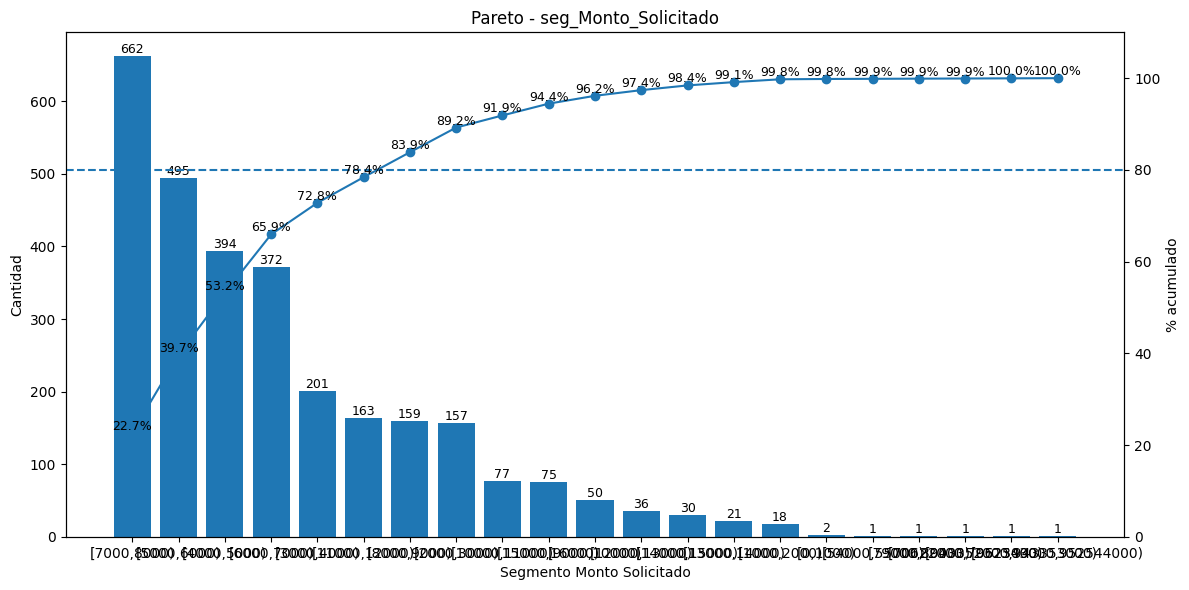

In [16]:
import matplotlib.pyplot as plt

df_ref = df_prueba.toPandas()

df_plot = (
    df_ref.groupby('seg_Monto_Solicitado')
    .size()
    .reset_index(name='cantidad')
    .sort_values('cantidad', ascending=False)
    .reset_index(drop=True)
)

df_plot['porcentaje'] = df_plot['cantidad'] / df_plot['cantidad'].sum() * 100
df_plot['porcentaje_acum'] = df_plot['porcentaje'].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(df_plot['seg_Monto_Solicitado'], df_plot['cantidad'])
ax1.set_xlabel("Segmento Monto Solicitado")
ax1.set_ylabel("Cantidad")

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom',
        fontsize=9
    )

ax2 = ax1.twinx()
ax2.plot(
    df_plot['seg_Monto_Solicitado'],
    df_plot['porcentaje_acum'],
    marker='o'
)
ax2.set_ylabel("% acumulado")
ax2.set_ylim(0, 110)

for i, val in enumerate(df_plot['porcentaje_acum']):
    ax2.text(
        i,
        val,
        f"{val:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

ax2.axhline(80, linestyle='--')

plt.title("Pareto - seg_Monto_Solicitado")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

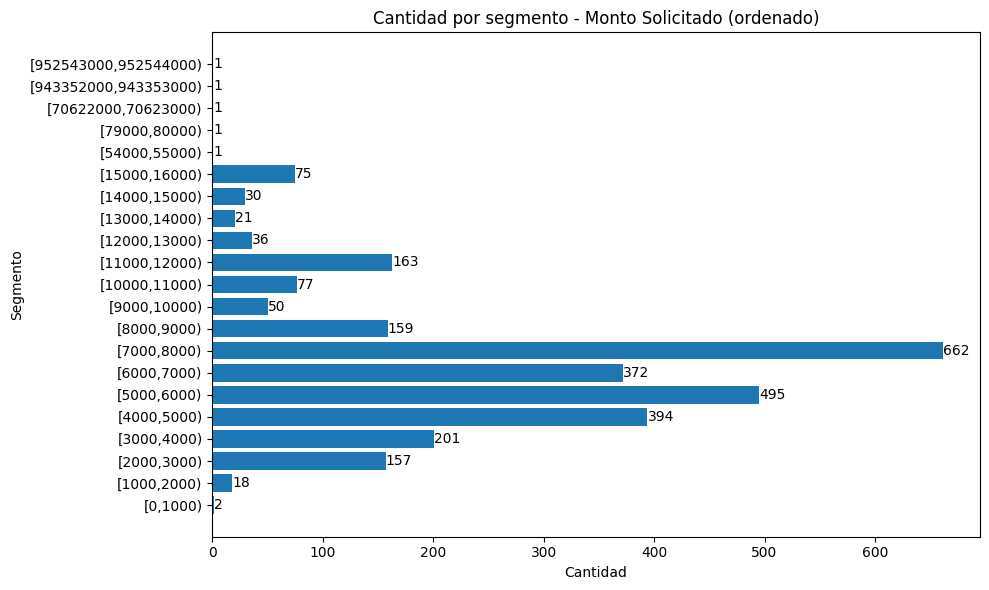

In [18]:
import matplotlib.pyplot as plt

# agrupar
df_plot = (
    df_ref.groupby('seg_Monto_Solicitado')
    .size()
    .reset_index(name='cantidad')
)

# extraer el inicio del rango (ej: 3000 de [3000,4000))
df_plot['orden'] = df_plot['seg_Monto_Solicitado'] \
    .str.extract(r'\[(\d+),')[0] \
    .astype(int)

# ordenar correctamente
df_plot = df_plot.sort_values('orden')

plt.figure(figsize=(10,6))

bars = plt.barh(df_plot['seg_Monto_Solicitado'], df_plot['cantidad'])

# etiquetas
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        str(int(width)),
        va='center'
    )

plt.xlabel("Cantidad")
plt.ylabel("Segmento")
plt.title("Cantidad por segmento - Monto Solicitado (ordenado)")

plt.tight_layout()
plt.show()

In [4]:
df_prueba=df_prueba.select('NUMERO_DOCUMENTO','Segmentacion','Fuente','Prioridad')

In [7]:
df_prueba.show()

+----------------+------------+-------+---------+
|NUMERO_DOCUMENTO|Segmentacion| Fuente|Prioridad|
+----------------+------------+-------+---------+
|        41387698|      5.BASE|Alpha 2|        3|
|        41375323|      5.BASE|Alpha 2|        4|
|        41389900|   3.PREMIUM|Alpha 2|        3|
|        07636038|      5.BASE|Alpha 2|        4|
|        41147062|   3.PREMIUM|Alpha 2|        4|
|        41060990|      5.BASE|Alpha 2|        4|
|        40908688|      5.BASE|Alpha 2|        3|
|        40083351|      5.BASE|Alpha 2|        3|
|        40015574|   3.PREMIUM|Alpha 2|        3|
|        32989335|      5.BASE|Alpha 2|        4|
|        40821812|   3.PREMIUM|Alpha 2|        2|
|        40780419|      5.BASE|Alpha 2|        4|
|        40711523|   3.PREMIUM|Alpha 2|        2|
|        32921330|      5.BASE|Alpha 2|        4|
|        41264621|      5.BASE|Alpha 2|        4|
|        41213918|      5.BASE|Alpha 2|        4|
|        41080628|      5.BASE|Alpha 2|        4|


In [ ]:
['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'NUEVO_GRUPO03', 'PROB_CONTACTO', 'DINERS_NRO1', 'DINERS_NRO2', 'DINERS_NRO3', 'DINERS_NRO4', 'DINERS_NRO5', 'OSIPTEL_NRO1_ENCRIP', 'OSIPTEL_NRO2_ENCRIP', 'OSIPTEL_NRO3_ENCRIP', 'OSIPTEL_NRO4_ENCRIP', 'OSIPTEL_NRO5_ENCRIP', 'DCP01', 'DCP02', 'DCP03', 'DCP04', 'DCP05', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'CELULAR04', 'CELULAR05', 'CELULAR06', 'CELULAR07', 'CELULAR08', 'CELULAR09', 'CELULAR10', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'EX_SOCIO', 'LINEA_ANT_EX_SOCIO', 'ULT_TASA_EX_SOCIO', 'Segmentacion', 'Prioridad', 'Fuente']


In [ ]:
df_prueba = df_prueba.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)
overwrite_table_SQL(spark,df_prueba,f'dinner_cyber_wow',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [4]:
overwrite_table_SQL(spark,df_prueba,f'dinner_cyber_wow',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [4]:
df_prueba=df_prueba.select('NUMERO_DOCUMENTO')


In [5]:
overwrite_table_SQL(spark,df_prueba,f'dinners_cash_borrar_actualizar__2',server_sa,user_sa,pwd_sa,'ODIN')
overwrite_table_SQL(spark,df_prueba,f'dinners_cash_borrar_actualizar__2',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba,f'dinners_cash_borrar_actualizar__2',server_zeus,user_zeus,pwd_zeus,'ODIN')
# overwrite_table_SQL(spark,df_prueba,f'dinners_cash_borrar_prioridad',server_datatg,user_datatg,pwd_datatg,'BD_DINERS_TC')


In [15]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

In [21]:
query = f"""
select *
    FROM valentina.dbo.alfcc_clientes
    where cl_base='abril 2026'
    
    """
df_base_p=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_base_p = df_base_p.toDF(*[c.lower() for c in df_base_p.columns])
df_base_p=df_base_p.select('numero_documento','cl_id', 'nombre')

filename='29_04 del 01 al 28.csv'
df_prueba=cargar_archivo_csv(spark,filename,';',True)
print(df_base_p.columns)
print(df_prueba.columns)


['numero_documento', 'cl_id', 'nombre']
['DNI', 'CLIENTE', 'TELEFONO']


In [ ]:

# filename='lista_di.csv'
# df_prueba=cargar_archivo_csv(spark,filename,';',True)
# print(df_prueba.columns)

['DNI']


In [17]:
df_prueba = df_prueba.withColumn(
    "DNI",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)
# overwrite_table_SQL(spark,df_prueba,f'dinner_cyber_300',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [22]:
df_base_p = df_base_p.withColumn(
    "numero_documento",
    F.right(
        F.concat(F.lit("00000000"), F.col("numero_documento")),
        F.lit(8)
    )
)
df_prueba = df_prueba.withColumn(
    "numero_documento",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)

In [23]:


df1=df_prueba.select(
    'numero_documento',
    'TELEFONO',
    F.lit(17).alias('uno')
).join(
    df_base_p.select('cl_id','numero_documento','nombre'),
    ['numero_documento'],
    'inner'
)
df1=df1.select('TELEFONO', 'cl_id', 'uno', 'nombre')
df1 = df1.withColumn(
    "col_final",
    F.concat_ws(",", "TELEFONO", "cl_id", "uno", "nombre")
)

df1 = df1.withColumn(
    "col_final",
    F.concat_ws("", "col_final", F.lit(","))
)
df1=df1.select('col_final')


In [24]:
import os
df_carga=df1.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'otro_credicash.csv')
df_carga.to_csv(ruta_archivo, index=False, sep=",",header=False)
# df_dni.to_excel(ruta_archivo, index=False)

In [8]:
spark.stop()

In [16]:
df_1=since_base_maestra_tc_dinners(spark)

In [17]:
df_1.show()

{"ts": "2026-04-24 13:25:11.626", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[CAST_INVALID_INPUT] The value '8/05/1973' of the type \"STRING\" cannot be cast to \"TIMESTAMP\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018", "context": {"file": "java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)", "line": "", "fragment": "months_between", "errorClass": "CAST_INVALID_INPUT"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o714.showString.\n: org.apache.spark.SparkDateTimeException: [CAST_INVALID_INPUT] The value '8/05/1973' of the type \"STRING\" cannot be cast to \"TIMESTAMP\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018\n== DataFrame ==\n\"months_betwee

DateTimeException: [CAST_INVALID_INPUT] The value '8/05/1973' of the type "STRING" cannot be cast to "TIMESTAMP" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018
== DataFrame ==
"months_between" was called from
java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)


In [ ]:

df_prueba=df_prueba.select('NUMERO_DOCUMENTO','SEGMENTACION')



In [4]:
query = f"""
    SELECT 
        a.CODDOC AS vendor_lead_code,
        t.phone_number,
        t.tipo_telf,
        a.CODDOC + ' ' + t.phone_number AS llave
    FROM DANTALION.dbo.Base_Maestra_Cencosud_PPFF a
    CROSS APPLY (
        VALUES
            {cross_list_cenco_ppff}
    ) t(tipo_telf,phone_number)
    WHERE CAST(fecha_envio AS DATE) >= DATEADD(MONTH, -1, CAST('2026-04-01' AS DATE))
    AND CAST(fecha_envio AS DATE) < DATEADD(MONTH, 0, CAST('2026-04-01' AS DATE))
    AND t.phone_number IS NOT NULL
    AND t.phone_number <> ''
    AND LEN(t.phone_number) = 9
    AND t.phone_number LIKE '9%'
    AND a.CODDOC IS NOT NULL
    """
df_base=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)


In [11]:
el_dni=dni_int
cross_columns=cross_columns_int
tb_a=tb_int
tb_b=tb_maestra_cenco_ppff
dni_maestra=dni_maestra_cenco_ppff
fecha_ref=fecha_ref_int
peso_ref=peso_int

In [12]:
print('el_dni',el_dni)
print('cross_columns',cross_columns)
print('tb_a',tb_a)
print('tb_b',tb_b)
print('dni_maestra',dni_maestra)
print('fecha_ref',fecha_ref)
print('peso_ref',peso_ref)


el_dni dni
cross_columns ('int01', a.int1),('int02', a.int2)
tb_a tConsoliddoNumerosInterno
tb_b base_maestra_cencosud_ppff
dni_maestra CODDOC
fecha_ref fecha
peso_ref 20


In [3]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

In [7]:
query = f"""
    SELECT 
        a.{el_dni} AS vendor_lead_code,
        t.phone_number,
        t.tipo_telf,
        DATEDIFF(DAY, a.{fecha_ref}, GETDATE()) AS dias_antiguedad,
        {peso_ref} as peso
    FROM DANTALION.dbo.{tb_a} a
    CROSS APPLY (
        VALUES {cross_columns}
    ) t(tipo_telf, phone_number)
    WHERE EXISTS (
        SELECT 1
        FROM DANTALION.dbo.{tb_b} b
        WHERE b.{dni_maestra} = a.{el_dni}
    )
    AND t.phone_number IS NOT NULL
    AND t.phone_number <> ''
    AND LEN(t.phone_number) = 9
    AND t.phone_number LIKE '9%'
    AND a.{el_dni} IS NOT NULL
    """
df_base=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

NameError: name 'el_dni' is not defined

In [15]:
df_base.show(2)

+----------------+------------+---------+---------------+----+
|vendor_lead_code|phone_number|tipo_telf|dias_antiguedad|peso|
+----------------+------------+---------+---------------+----+
|        23710094|   966412429|    int01|            415|  20|
|        07669252|   993416243|    int01|            415|  20|
+----------------+------------+---------+---------------+----+
only showing top 2 rows


In [ ]:

def pool_tnumeros_valentina(el_dni,cross_columns_epc,tb_a,tb_b):
    query = f"""
    SELECT 
        a.{el_dni} AS vendor_lead_code,
        t.phone_number,
        t.tipo_telf,
        a.{el_dni} + ' ' + t.phone_number AS llave
    FROM DANTALION.dbo.{tb_a} a

    CROSS APPLY (
        VALUES {cross_columns_epc}
    ) t(tipo_telf, phone_number)

    WHERE EXISTS (
        SELECT 1
        FROM DANTALION.dbo.{tb_b} b
        WHERE b.CODDOC = a.{el_dni}
    )
    AND t.phone_number IS NOT NULL
    AND t.phone_number <> ''
    AND LEN(t.phone_number) = 9
    AND t.phone_number LIKE '9%'
    AND a.{el_dni} IS NOT NULL
    """
    df_base=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

In [1]:
fecha_mes_base='2026-04-01'

In [9]:
tb_valentina_cliente

NameError: name 'tb_valentina_cliente' is not defined

In [10]:
tb_valentina_cliente='alfcc_clientes'

In [11]:
# def since_tnumeros_valentina(spark,tb_valentina_cliente,fecha_mes_base):
cl_base1 = fecha_a_nombre(fecha_mes_base)
query = f"""
    SELECT 
    a.NUMERO_DOCUMENTO as dni_cliente,
    t.contacto,
    t.tipo_telf,
    a.cl_carga
    FROM VALENTINA.dbo.{tb_valentina_cliente} a
    CROSS APPLY (
    VALUES
        (a.cl_telf1, 'cel01'),
        (a.cl_telf2, 'cel02'),
        (a.cl_telf3, 'cel03'),
        (a.cl_telf4, 'cel04'),
        (a.cl_telf5, 'cel05'),
        (a.cl_telf6, 'cel06'),
        (a.cl_telf7, 'cel07'),
        (a.cl_telf8, 'cel08'),
        (a.cl_telf9, 'cel09'),
        (a.cl_telf10, 'cel10')
    ) t(contacto, tipo_telf)
    WHERE 
    t.contacto IS NOT NULL
    AND t.contacto <> ''
    AND LEN(t.contacto) = 9
    AND t.contacto LIKE '9%'
    and cl_base='{cl_base1}'
    """
df_tnumero=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("cl_carga").desc_nulls_last())
df_tnumero = df_tnumero.withColumn("ref_01", row_number().over(window_spec))
# return df_tnumero.filter(F.col("ref_01") == 1).drop('ref_01','cl_carga')


In [ ]:

df_tnumero.show()

+-----------+---------+---------+----------+------+
|dni_cliente| contacto|tipo_telf|  cl_carga|ref_01|
+-----------+---------+---------+----------+------+
|   00001614|961021360|    cel01|2026-04-01|     1|
|   00001614|993934509|    cel02|2026-04-01|     2|
|   00002841|950675358|    cel01|2026-04-01|     1|
|   00003051|961514580|    cel01|2026-04-01|     1|
|   00003397|984547830|    cel01|2026-04-01|     1|
|   00003397|941807979|    cel02|2026-04-01|     2|
|   00005819|939401060|    cel01|2026-04-01|     1|
|   00006005|945061005|    cel01|2026-04-01|     1|
|   00007085|955558212|    cel01|2026-04-01|     1|
|   00007306|958825429|    cel01|2026-04-01|     1|
|   00008836|991475250|    cel01|2026-04-01|     1|
|   00008836|948455196|    cel02|2026-04-01|     2|
|   00013716|961089250|    cel01|2026-04-01|     1|
|   00013716|935992450|    cel02|2026-04-01|     2|
|   00014922|964568263|    cel01|2026-04-01|     1|
|   00015400|947248179|    cel01|2026-04-01|     1|
|   00016727

In [11]:
df_base.show()

+----------------+------------+---------+------------------+
|vendor_lead_code|phone_number|tipo_telf|             llave|
+----------------+------------+---------+------------------+
|        80247025|   959899087|    nmt01|80247025 959899087|
|        80247025|   920266091|    nmt02|80247025 920266091|
|        80236465|   941741350|    nmt01|80236465 941741350|
|        80236465|   940429758|    nmt02|80236465 940429758|
|        80236465|   993759220|    nmt03|80236465 993759220|
|        80241516|   965683050|    nmt01|80241516 965683050|
|        80241516|   973954088|    nmt02|80241516 973954088|
|        80241516|   985088803|    nmt03|80241516 985088803|
|        77680116|   970280683|    nmt01|77680116 970280683|
|        77680116|   984242465|    nmt02|77680116 984242465|
|        77680116|   982654230|    nmt03|77680116 982654230|
|        80260302|   945060827|    nmt01|80260302 945060827|
|        80260302|   932780437|    nmt02|80260302 932780437|
|        80260302|   948

In [ ]:
soverwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [ ]:
EXEC ('UPDATE alfin_clientes
SET MES_DURACION_BASE = ''04'',
    ANIO_DURACION_BASE = ''2026''
WHERE cl_base = ''Abril 2026''') 
AT [192.168.3.90];



In [ ]:
query = f"""
 update a
set RECENCIA='nose'
from CRONOX.dbo.tb_prueba_borrar_dinner_prestamo a
where dni='41451805'
    """


In [11]:
ejecutar_sql_server(server_sa,db_sa,user_sa,pwd_sa,query)

In [ ]:
query = f"""
    select top(1)* 
    from openquery([192.168.3.90],'Select 
    ,0 as cl_telf1
    ,0 as cl_telf2
    ,0 as cl_telf3
    ,0 as cl_telf4
    ,0 as cl_movil
    ,0 as cl_telefono
    ,0 as cl_turno
    ,0 as cl_gestor
    ,0 as cl_asesor
    ,0 as cl_gestion
    ,0 as cl_estado
    ,0 as cl_hits
    ,0 as cl_prioridad
    ,0 as cl_orden
    ,0 as cl_predictivo
    ,0 as cl_tiempo
    ,0 as cl_area
    from alfin_clientes where cl_base="Abril 2026"');
    """
df_base=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)


In [ ]:
INSERT INTO OPENQUERY([192.168.3.90], '
    SELECT cl_id, cl_telf1, cl_telf2, cl_base
    FROM alfcc_clientes
')
SELECT cl_id, cl_telf1, cl_telf2, cl_base
FROM dbo.stg_alfcc_clientes;

In [ ]:
INSERT INTO OPENQUERY([192.168.3.90], '
    SELECT campo1, campo2, campo3
    FROM bd_mysql.tabla_destino
')
SELECT campo1, campo2, campo3
FROM tabla_staging_sqlserver;

In [2]:
filename='dinnesssssssssssssssssssssssssssssssssss_1.csv'
df_prueba=cargar_archivo_csv(spark,filename,';',True)

print(df_prueba.columns)

['DNI']


In [3]:

df_prueba = df_prueba.withColumn(
    "DNI",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)


In [ ]:
['PROPENSION_IC', 'USER_V3', 'NUMERO_DOCUMENTO', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES', 'OFERTA_MAX', 'tasa_minima', 'PLAZO', 'CUOTA', 'CAPACIDAD_MAX', 'TIPO_GEST', 'TIPO_CLIENTE_COMERCIAL', 'campania', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final', 'PERFIL_RO', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'SUCURSAL_COMERCIAL', 'Agencia_comercial', 'REGION_COMERCIAL', 'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR', 'VARIACION_TASA_CAMPAÃ‘A_ANTERIOR', 'VAR_TASA_CREDITO_ANTERIOR', 'FLG_CET_6M', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'GRUPO_MONTO', 'MGNEG', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'Edad', 'RANGO_EDAD', 'RANGO_OFERTA', 'RANGO_SUELDO', 'BLOQUE', 'FRESCURA', 'FLG_AAHH', 'INTENSIDAD_MAX', 'PILOTO_PLAZAS', 'CAMP_BONO', 'CAMP_ADP']
['NUMERO_DOCUMENTO', 'cl_telf1', 'cl_telf2', 'SCORE_TELEFONO', '_c4']

In [4]:
df_prueba=df_prueba.withColumnRenamed('X_APPATERNO','APELLIDO_PATERNO')
df_prueba=df_prueba.withColumnRenamed('X_APMATERNO','APELLIDO_MATERNO')
df_prueba=df_prueba.withColumnRenamed('CampaÃ±a','campania')
df_prueba=df_prueba.withColumnRenamed('X_NOMBRE','NOMBRES')
df_prueba=df_prueba.withColumnRenamed('DNI','NUMERO_DOCUMENTO')


In [5]:
df_score = df_score.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)

df_prueba = df_prueba.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)

df_prueba=df_prueba.drop('SCORE_TELEFONO')

df_score=df_score.select('NUMERO_DOCUMENTO', 'cl_telf1', 'cl_telf2', 'SCORE_TELEFONO')

In [6]:
df_prueba = df_prueba.withColumn("TIENDA", F.col("Agencia_comercial"))
df_prueba = df_prueba.withColumn("SUCURSAL", F.col("Agencia_comercial"))
df_prueba = df_prueba.withColumn("LOTE", F.lit("BASE 2026-04-18"))
df_prueba = df_prueba.withColumn("cl_base", F.lit("Abril 2026"))
df_prueba = df_prueba.withColumn("cl_carga", F.lit("2026-04-18"))
df_prueba = df_prueba.withColumn("ESTADO", F.lit("ACTIVO"))
df_prueba = df_prueba.withColumn("CAMPANA", F.lit("202604"))
df_prueba = df_prueba.withColumn("nombre_base", F.lit("2026-04-18"))


In [7]:
df_prueba=df_prueba.join(df_score,['NUMERO_DOCUMENTO'],'left')
print(df_prueba.columns)


['NUMERO_DOCUMENTO', 'PROPENSION_IC', 'USER_V3', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES', 'OFERTA_MAX', 'tasa_minima', 'PLAZO', 'CUOTA', 'CAPACIDAD_MAX', 'TIPO_GEST', 'TIPO_CLIENTE_COMERCIAL', 'campania', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final', 'PERFIL_RO', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'SUCURSAL_COMERCIAL', 'Agencia_comercial', 'REGION_COMERCIAL', 'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR', 'VARIACION_TASA_CAMPAÃ‘A_ANTERIOR', 'VAR_TASA_CREDITO_ANTERIOR', 'FLG_CET_6M', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'GRUPO_MONTO', 'MGNEG', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'Edad', 'RANGO_EDAD', 'RANGO_OFERTA', 'RANGO_SUELDO', 'BLOQUE', 'FRESCURA', 'FLG_AAHH', 'INTENSIDAD_MAX', 'PILOTO_PLAZAS', 'CAMP_BONO', 'CAMP_ADP', 'TIENDA', 'SUCURSAL', 'LOTE', 'cl_base', 'cl_carga', 'ESTADO', 'CAMPANA', 'nombre_base', 'cl_telf1', 'cl_telf2', 'SCORE_TELEFONO']


In [ ]:
query = f"""
    select top(1)* 
    from openquery([192.168.3.90],'Select 
    ,0 as cl_telf1
    ,0 as cl_telf2
    ,0 as cl_telf3
    ,0 as cl_telf4
    ,0 as cl_movil
    ,0 as cl_telefono
    ,0 as cl_turno
    ,0 as cl_gestor
    ,0 as cl_asesor
    ,0 as cl_gestion
    ,0 as cl_estado
    ,0 as cl_hits
    ,0 as cl_prioridad
    ,0 as cl_orden
    ,0 as cl_predictivo
    ,0 as cl_tiempo
    ,0 as cl_area
    from alfin_clientes where cl_base="Abril 2026"');
    """
df_base=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)


In [ ]:
query = f"""
    SELECT [ID PROVEEDOR]
      ,[NOMBRES]
      ,[APELLIDO PATERNO]
      ,[APELLIDO MATERNO]
      ,[TIPO DE DOCUMENTO]
      ,[NUMERO_DOCUMENTO]
      ,[TASA(TEA)]
      ,[TEA_DF]
      ,[TELEFONO_CASA1]
      ,[TELEFONO_CASA2]
      ,[TELEFONO_CASA3]
      ,[TELEFONO_CASA4]
      ,[TELEFONO_CASA5]
      ,[TELEFONO_CASA6]
      ,[TELEFONO_CASA7]
      ,[TELEFONO_CASA8]
      ,[TELEFONO_CASA9]
      ,[TELEFONO_CASA10]
      ,[CELULAR1]
      ,[CELULAR2]
      ,[CELULAR3]
      ,[CELULAR4]
      ,[CELULAR5]
      ,[CELULAR6]
      ,[CELULAR7]
      ,[CELULAR8]
      ,[CELULAR9]
      ,[CELULAR10]
      ,[PERFIL]
      ,[PRODUCTO]
      ,[LINEA CREDITO DOLARES]
      ,[ID RESULTADO GESTION]
      ,[TCEA]
      ,[TCEA_CUOTAS_DF]
      ,[LIMAPROVINCIA]
      ,[GRUPO_EJECUCION]
      ,[FEC_NAC]
      ,[PROVINCIA]
      ,[L_BCP]
      ,[L_BBVA]
      ,[L_IBK]
      ,[L_SCO]
      ,[L_BIF]
      ,[L_CITI]
      ,[L_FIN]
      ,[L_RIP]
      ,[L_CMR]
      ,[L_CRESCO]
      ,[L_CEN]
      ,[L_AZT]
      ,[L_UNO]
      ,[L_GNB]
      ,[L_EFE]
      ,[L_COM]
      ,[L_NAC]
      ,[RECURRENCIA]
      ,[CEL01]
      ,[CEL02]
      ,[CEL03]
      ,[CEL04]
      ,[CEL05]
      ,[CEL06]
      ,[CEL07]
      ,[CEL08]
      ,[CEL09]
      ,[CEL10]
      ,[TELF1]
      ,[TELF2]
      ,[TELF3]
      ,[TELF4]
      ,[TELF5]
      ,[TELF6]
      ,[TELF7]
      ,[TELF8]
      ,[FECHA_ENVIO]
      ,[MES_DURACION_BASE]
      ,[AÑO_DURACION_BASE]
      ,[SERVICIO]
      ,[RETIRO]
      ,[MARCA]
      ,[MARCA2]
      ,[FLAT1]
      ,[FLAT2]
      ,[FLAT3]
      ,[REP1]
      ,[REP2]
      ,[TASA_ANT]
      ,[TCEA_ANT]
      ,[FLG_BT]
      ,[MONTO_OFERTA_BT]
      ,[PRIORIDAD_TELEFONO_1]
      ,[PRIORIDAD_TELEFONO_2]
      ,[PRIORIDAD_TELEFONO_3]
      ,[PRIORIDAD_TELEFONO_4]
      ,[PRIORIDAD_TELEFONO_5]
    FROM [DANTALION].[dbo].[Base_Maestra_Diners_TC]
    where fecha_envio='2026-04-24'
    """
df_base=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)
print(df_base.columns)

['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'CELULAR1', 'CELULAR2', 'CELULAR3', 'CELULAR4', 'CELULAR5', 'CELULAR6', 'CELULAR7', 'CELULAR8', 'CELULAR9', 'CELULAR10', 'PERFIL', 'PRODUCTO', 'LINEA CREDITO DOLARES', 'ID RESULTADO GESTION', 'TCEA', 'TCEA_CUOTAS_DF', 'LIMAPROVINCIA', 'GRUPO_EJECUCION', 'FEC_NAC', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'RECURRENCIA', 'CEL01', 'CEL02', 'CEL03', 'CEL04', 'CEL05', 'CEL06', 'CEL07', 'CEL08', 'CEL09', 'CEL10', 'TELF1', 'TELF2', 'TELF3', 'TELF4', 'TELF5', 'TELF6', 'TELF7', 'TELF8', 'FECHA_ENVIO', 'MES_DURACION_BASE', 'AÑO_DURACION_BASE', 'SERVICIO', 'RETI

In [25]:
df_base=df_base.select('ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'CELULAR1', 'CELULAR2', 'CELULAR3', 'CELULAR4', 'CELULAR5', 'CELULAR6', 'CELULAR7', 'CELULAR8', 'CELULAR9', 'CELULAR10', 'PERFIL', 'PRODUCTO', 'LINEA CREDITO DOLARES', 'ID RESULTADO GESTION', 'TCEA', 'TCEA_CUOTAS_DF', 'LIMAPROVINCIA', 'GRUPO_EJECUCION', 'FEC_NAC', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'RECURRENCIA', 'CEL01', 'CEL02', 'CEL03', 'CEL04', 'CEL05', 'CEL06', 'CEL07', 'CEL08', 'CEL09', 'CEL10', 'TELF1', 'TELF2', 'TELF3', 'TELF4', 'TELF5', 'TELF6', 'TELF7', 'TELF8', 'FECHA_ENVIO', 'MES_DURACION_BASE', 'AÑO_DURACION_BASE', 'SERVICIO', 'RETIRO', 'MARCA', 'MARCA2', 'FLAT1', 'FLAT2', 'FLAT3', 'REP1', 'REP2', 'TASA_ANT', 'TCEA_ANT', 'FLG_BT', 'MONTO_OFERTA_BT', 'PRIORIDAD_TELEFONO_1', 'PRIORIDAD_TELEFONO_2', 'PRIORIDAD_TELEFONO_3', 'PRIORIDAD_TELEFONO_4', 'PRIORIDAD_TELEFONO_5' )

In [30]:
db_datatg

'BD_DINERS_TC'

In [32]:

# append_table_SQL(spark,df_prueba,'Tbl_base_hist',server_datatg,user_datatg,pwd_datatg,'BD_DINERS_TC')



append_table_SQL(spark,df_prueba,f'borrar_dinner_actualziar_envio_hoy_2',server_datatg,user_datatg,pwd_datatg,'BD_DINERS_TC')


In [ ]:
user_datatg = "DataTg"
pwd_datatg = "target2024$$"
server_datatg = "192.168.3.26"
db_datatg = "BD_DINERS_TC"


In [8]:
from pyspark.sql import functions as F

cols_patron = [
    'NUMERO_DOCUMENTO', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES',
    'SUCURSAL', 'TIENDA', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion',
    'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7',
    'PLAZO', 'campania', 'TEM', 'Desgravamen', 'CUOTA', 'Edad',
    'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M',
    'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M',
    'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M',
    'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M',
    'Validador_Telefono', 'Prioridad', 'Nombre_prioridad',
    'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3',
    'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'sucursal_comercial',
    'Agencia_comercial', 'Region_comercial', 'RANGO_EDAD', 'RANGO_OFERTA',
    'RANGO_SUELDO', 'CAPACIDAD_MAX', 'PEER', 'TIPO_GEST', 'TIPO_CLIENTE',
    'CLIENTE_NUEVO', 'GRUPO_TASA', 'GRUPO_MONTO', 'TASA_VS_MONTO',
    'GRUPO_TASA_REENGANCHE', 'SALDO_DIFERENCIAL_REENG', 'FLAG_REENG',
    'color', 'color_final', 'PROPENSION', 'SEGMENTO_USER', 'USUARIO',
    'tipo_cliente_riegos', 'incremento_monto_riesgos', 'FLG_DEUDA_PLUS',
    'FRESCURA', 'LEAD_CALIDAD', 'USER_V3', 'TIPO_BASE',
    'flag_deuda_v_oferta', 'MGNEG', 'PROPENSION_IC', 'PERFIL_RO',
    'FLG_AAHH', 'SCORE_TELEFONO', 'NumEntidades', 'INTENSIDAD_MAX',
    'nombre_base', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4',
    'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9',
    'cl_telf10', 'LOTE', 'ESTADO', 'CAMPANA', 'cl_base', 'tasa_minima',
    'cl_carga', 'MES_DURACION_BASE', 'ANIO_DURACION_BASE', 'PERFIL_GLOBAL'
]

# Crear columnas faltantes
for col in cols_patron:
    if col not in df_prueba.columns:
        df_prueba = df_prueba.withColumn(col, F.lit(None))

# Seleccionar exactamente en ese orden
df_prueba = df_prueba.select(cols_patron)

In [ ]:



df_dni = df_prueba.toPandas()
import os

ruta_archivo = os.path.join(ruta_csv, 'BASE_ALFIN_20260418.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [20]:
df_prueba.show(5)


+----------------+-------------+--------+----------------+----------------+-----------------+----------+-----------+-----+------+-------------+---------+----------------------+--------+-----------------------+-------------+---------------+---------+----------------+------------+-------------+----------+------------------+-----------------+--------------------+---------------------------------+-------------------------------+-------------------------+----------+-------------------+-------------+---------------+-----+------+------+------+------+------+------+------+----+----------+------------+------------+------+--------+------------+--------------+-------------+------------+--------+-------------+-------------+----------+---------+----------+------+-------+-----------+---------+---------+--------------+
|NUMERO_DOCUMENTO|PROPENSION_IC| USER_V3|APELLIDO_PATERNO|APELLIDO_MATERNO|          NOMBRES|OFERTA_MAX|tasa_minima|PLAZO| CUOTA|CAPACIDAD_MAX|TIPO_GEST|TIPO_CLIENTE_COMERCIAL|campania|

In [2]:
query = f"""
select *
    FROM valentina.dbo.alfin_clientes
    where cl_base='abril 2026'
    """
df_base_p=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_base_p = df_base_p.toDF(*[c.lower() for c in df_base_p.columns])
print(df_base_p.columns)

['cl_id', 'tipo_doi', 'numero_documento', 'nombres', 'apellido_paterno', 'apellido_materno', 'sucursal', 'tienda', 'departamento', 'provincia', 'distrito', 'fec_nacimiento', 'oferta_max', 'oferta_reen', 'tipo_verificacion', 'grupo_riesgo', 'proveedor', 'lote', 'estado', 'tasa_1', 'tasa_2', 'tasa_3', 'tasa_4', 'tasa_5', 'tasa_6', 'tasa_7', 'segmento', 'campana', 'plazo', 'tem', 'propension_ic', 'desgravamen', 'cuota', 'edad', 'oferta_12m', 'tasa_12m', 'desgravamen_12m', 'cuota_12m', 'oferta_18m', 'tasa_18m', 'desgravamen_18m', 'cuota_18m', 'oferta_24m', 'tasa_24m', 'desgravamen_24m', 'cuota_24m', 'oferta_36m', 'tasa_36m', 'desgravamen_36m', 'cuota_36m', 'validador_telefono', 'prioridad', 'nombre_prioridad', 'deuda_1', 'entidad_1', 'deuda_2', 'entidad_2', 'deuda_3', 'entidad_3', 'sucursal_comercial', 'agencia_comercial', 'region_comercial', 'ubicacion', 'ofertamaximasinseguro', 'color', 'color_final', 'propension', 'oferta_final', 'garantia', 'oferta_minima_paperless', 'rango_oferta', 'r

In [3]:
df_base_p=df_base_p.select('numero_documento','cl_id','nombres','apellido_paterno')

In [ ]:
# query = f"""
# select *
#     FROM valentina.dbo.alfin_clientes
#     where cl_base='abril 2026'
#     """
# df_base_p=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
# df_base_p = df_base_p.toDF(*[c.lower() for c in df_base_p.columns])
# print(df_base_p.columns)


['cl_id', 'tipo_doi', 'numero_documento', 'nombres', 'apellido_paterno', 'apellido_materno', 'sucursal', 'tienda', 'departamento', 'provincia', 'distrito', 'fec_nacimiento', 'oferta_max', 'oferta_reen', 'tipo_verificacion', 'grupo_riesgo', 'proveedor', 'lote', 'estado', 'tasa_1', 'tasa_2', 'tasa_3', 'tasa_4', 'tasa_5', 'tasa_6', 'tasa_7', 'segmento', 'campana', 'plazo', 'tem', 'propension_ic', 'desgravamen', 'cuota', 'edad', 'oferta_12m', 'tasa_12m', 'desgravamen_12m', 'cuota_12m', 'oferta_18m', 'tasa_18m', 'desgravamen_18m', 'cuota_18m', 'oferta_24m', 'tasa_24m', 'desgravamen_24m', 'cuota_24m', 'oferta_36m', 'tasa_36m', 'desgravamen_36m', 'cuota_36m', 'validador_telefono', 'prioridad', 'nombre_prioridad', 'deuda_1', 'entidad_1', 'deuda_2', 'entidad_2', 'deuda_3', 'entidad_3', 'sucursal_comercial', 'agencia_comercial', 'region_comercial', 'ubicacion', 'ofertamaximasinseguro', 'color', 'color_final', 'propension', 'oferta_final', 'garantia', 'oferta_minima_paperless', 'rango_oferta', 'r

In [ ]:
['cl_id', 'tipo_doi', 'numero_documento', 'nombres', 'apellido_paterno', 'apellido_materno', 'sucursal', 'tienda', 'departamento', 'provincia', 'distrito', 'fec_nacimiento', 'oferta_max', 'oferta_reen', 'tipo_verificacion', 'grupo_riesgo', 'proveedor', 'lote', 'estado', 'tasa_1', 'tasa_2', 'tasa_3', 'tasa_4', 'tasa_5', 'tasa_6', 'tasa_7', 'segmento', 'campana', 'plazo', 'tem', 'propension_ic', 'desgravamen', 'cuota', 'edad', 'oferta_12m', 'tasa_12m', 'desgravamen_12m', 'cuota_12m', 'oferta_18m', 'tasa_18m', 'desgravamen_18m', 'cuota_18m', 'oferta_24m', 'tasa_24m', 'desgravamen_24m', 'cuota_24m', 'oferta_36m', 'tasa_36m', 'desgravamen_36m', 'cuota_36m', 'validador_telefono', 'prioridad', 'nombre_prioridad', 'deuda_1', 'entidad_1', 'deuda_2', 'entidad_2', 'deuda_3', 'entidad_3', 'sucursal_comercial', 'agencia_comercial', 'region_comercial', 'ubicacion', 'ofertamaximasinseguro', 'color', 'color_final', 'propension', 'oferta_final', 'garantia', 'oferta_minima_paperless', 'rango_oferta', 'rango_sueldo', 'capacidad_max', 'peer', 'prop_comer', 'tipo_gest', 'cliente_nuevo', 'grupo_tasa', 'nuevos_3m', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_4m', 'grupo_monto', 'tasa_vs_monto', 'usuario', 'incremento_monto_riesgos', 'flg_deuda_plus', 'tipo_cliente_riegos', 'user_v3', 'lead_calidad', 'segmento_user', 'rango_edad', 'rango_oferta2', 'periodo', 'retiro_gest', 'mejor_tipificacion', 'status', 'fecha_sol', 'base', 'resultado', 'num_enriquecido', 'tipo_contacto', 'q_ventas', 'localidad', 'desembolsado', 'monto_desembolsado', 'sbi', 'cruce', 'prest_previo', 'id_cliente', 'rango_edad2', 'fecha_envio', 'tipo_bd', 'cod_bd', 'nomb_bd', 'mes_gestion', 'tipo_cliente', 'grupo_tasa_reenganche', 'saldo_diferencial_reeng', 'flag_reeng', 'retiro_desembolso', 'frescura', 'flag_deuda_v_oferta', 'mgneg', 'perfil_ro', 'tipo_base', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono', 'cl_turno', 'cl_gestor', 'cl_asesor', 'cl_accion', 'cl_gestion', 'cl_estado', 'cl_fecha_gestion', 'cl_hora_gestion', 'cl_hits', 'cl_fecha_llamar', 'cl_prioridad', 'cl_orden', 'cl_predictivo', 'cl_tiempo', 'cl_base', 'cl_mes', 'cl_carga', 'id_carga', 'cl_area', 'fecha_alimentacion', 'cl_base_ant', 'cl_accion_ant', 'cl_fecha_ant', 'campania', 'promocion', 'promocion2', 'nombre_base', 'numentidades', 'p_banco', 'perfil_global', 'flg_aahh', 'score_telefono', 'piloto_plazas', 'intensidad_max']tasa


In [8]:
df_base_p=df_base_p.select('numero_documento','cl_id', 'nombre')


In [6]:
from pyspark.sql.functions import lit

df1=df_prueba.select(
    'numero_documento',
    'CELULAR',
    lit(12).alias('uno')
).join(
    df_base_p.select('cl_id','numero_documento','nombres', 'apellido_paterno'),
    ['numero_documento'],
    'inner'
)

In [7]:
df1=df1.select('CELULAR', 'cl_id', 'uno', 'nombres','apellido_paterno')
df1 = df1.withColumn(
    "col_final",
    F.concat_ws(",", "CELULAR", "cl_id", "uno", "nombres",'apellido_paterno')
)

df1 = df1.withColumn(
    "col_final",
    F.concat_ws("", "col_final", lit(","))
)
df1=df1.select('col_final')

import os
df_carga=df1.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'subir_alf.csv')
df_carga.to_csv(ruta_archivo, index=False, sep=",",header=False)
# df_dni.to_excel(ruta_archivo, index=False)

In [22]:
append_table_SQL(spark,df_prueba,f'borrar_dinner_actualziar',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [20]:
filename='TARGET_202604_CH.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
# print(df_base_p.columns)
print(df_prueba.columns)

['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'NUEVO_GRUPO03', 'PROB_CONTACTO', 'DINERS_NRO1', 'DINERS_NRO2', 'DINERS_NRO3', 'DINERS_NRO4', 'DINERS_NRO5', 'OSIPTEL_NRO1_ENCRIP', 'OSIPTEL_NRO2_ENCRIP', 'OSIPTEL_NRO3_ENCRIP', 'OSIPTEL_NRO4_ENCRIP', 'OSIPTEL_NRO5_ENCRIP', 'DCP01', 'DCP02', 'DCP03', 'DCP04', 'DCP05', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'CELULAR04', 'CELULAR05', 'CELULAR06', 'CELULAR07', 'CELULAR08', 'CELULAR09', 'CELULAR10', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 

In [21]:
df_prueba = df_prueba.withColumn(
    "numero_documento",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)


{"ts": "2026-04-24 16:55:26.871", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `DNI` cannot be resolved. Did you mean one of the following? [`DCP01`, `DCP02`, `DCP03`, `DCP04`, `DCP05`]. SQLSTATE: 42703", "context": {"file": "jdk.internal.reflect.GeneratedMethodAccessor49.invoke(Unknown Source)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o175.withColumn.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `DNI` cannot be resolved. Did you mean one of the following? [`DCP01`, `DCP02`, `DCP03`, `DCP04`, `DCP05`]. SQLSTATE: 42703;\n'Project [ID PROVEEDOR#83, NOMBRES#84, APELLIDO PATERNO#85, APELLIDO MATERNO#86, TIPO DE DOCUMENTO#87, 'right('concat(00000000, 'DNI), 8) AS numero_documen

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `DNI` cannot be resolved. Did you mean one of the following? [`DCP01`, `DCP02`, `DCP03`, `DCP04`, `DCP05`]. SQLSTATE: 42703;
'Project [ID PROVEEDOR#83, NOMBRES#84, APELLIDO PATERNO#85, APELLIDO MATERNO#86, TIPO DE DOCUMENTO#87, 'right('concat(00000000, 'DNI), 8) AS numero_documento#159, TASA(TEA)#89, TEA_DF#90, TELEFONO_CASA1#91, TELEFONO_CASA2#92, TELEFONO_CASA3#93, TELEFONO_CASA4#94, TELEFONO_CASA5#95, TELEFONO_CASA6#96, TELEFONO_CASA7#97, TELEFONO_CASA8#98, TELEFONO_CASA9#99, TELEFONO_CASA10#100, NUEVO_GRUPO03#101, PROB_CONTACTO#102, DINERS_NRO1#103, DINERS_NRO2#104, DINERS_NRO3#105, DINERS_NRO4#106, DINERS_NRO5#107, ... 50 more fields]
+- Relation [ID PROVEEDOR#83,NOMBRES#84,APELLIDO PATERNO#85,APELLIDO MATERNO#86,TIPO DE DOCUMENTO#87,NUMERO_DOCUMENTO#88,TASA(TEA)#89,TEA_DF#90,TELEFONO_CASA1#91,TELEFONO_CASA2#92,TELEFONO_CASA3#93,TELEFONO_CASA4#94,TELEFONO_CASA5#95,TELEFONO_CA

In [ ]:
# overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_sa,user_sa,pwd_sa,'ODIN')


In [10]:
print(df_base_p.columns)
print(df_prueba.columns)

['numero_documento', 'cl_id', 'nombre']
['DNI', 'CLIENTE', 'TELEFONO', 'numero_documento']


In [11]:
from pyspark.sql.functions import lit

df1=df_prueba.select(
    'numero_documento',
    'TELEFONO',
    lit(17).alias('uno')
).join(
    df_base_p.select('cl_id','numero_documento','nombre'),
    ['numero_documento'],
    'inner'
)

In [12]:
print(df1.columns)


['numero_documento', 'TELEFONO', 'uno', 'cl_id', 'nombre']


In [13]:
df1=df1.select('TELEFONO', 'cl_id', 'uno', 'nombre')
df1 = df1.withColumn(
    "col_final",
    F.concat_ws(",", "TELEFONO", "cl_id", "uno", "nombre")
)

df1 = df1.withColumn(
    "col_final",
    F.concat_ws("", "col_final", lit(","))
)
df1=df1.select('col_final')


In [ ]:
import os
df_carga=df1.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'subir_cred.csv')
df_carga.to_csv(ruta_archivo, index=False, sep=",",header=False)
# df_dni.to_excel(ruta_archivo, index=False)

In [7]:
filename='fugas_dni.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
print(df_prueba.columns)

['dni']


In [ ]:
['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'NUEVO_GRUPO03', 'PROB_CONTACTO', 'DINERS_NRO1', 'DINERS_NRO2', 'DINERS_NRO3', 'DINERS_NRO4', 'DINERS_NRO5', 'OSIPTEL_NRO1_ENCRIP', 'OSIPTEL_NRO2_ENCRIP', 'OSIPTEL_NRO3_ENCRIP', 'OSIPTEL_NRO4_ENCRIP', 'OSIPTEL_NRO5_ENCRIP', 'DCP01', 'DCP02', 'DCP03', 'DCP04', 'DCP05', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'CELULAR04', 'CELULAR05', 'CELULAR06', 'CELULAR07', 'CELULAR08', 'CELULAR09', 'CELULAR10', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'EX_SOCIO', 'LINEA_ANT_EX_SOCIO', 'ULT_TASA_EX_SOCIO', 'PRIORIDAD', 'BENCH', 'FUENTE', 'SEGMENTACION']

In [4]:
df_prueba=df_prueba.select('NUMERO_DOCUMENTO','SEGMENTACION')

In [8]:
df_prueba = df_prueba.withColumn(
    "numero_documento",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni")),
        F.lit(8)
    )
)

In [23]:
df_prueba=df_prueba.select('numero_documento')

In [9]:
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_sa,user_sa,pwd_sa,'ODIN')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_zeus,user_zeus,pwd_zeus,'ODIN')


In [ ]:
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_sa,user_sa,pwd_sa,'ODIN')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_zeus,user_zeus,pwd_zeus,'ODIN')


In [ ]:
fecha_mes_base='2026-04-01'
query = f"""
    SELECT 
    a.NUMERO_DOCUMENTO as dni_cliente,
    t.contacto,
    t.tipo_telf,
    a.cl_carga
    FROM VALENTINA.dbo.alfin_clientes a
    CROSS APPLY (
    VALUES
        (a.cl_telf1, 'cel01'),
        (a.cl_telf2, 'cel02'),
        (a.cl_telf3, 'cel03'),
        (a.cl_telf4, 'cel04'),
        (a.cl_telf5, 'cel05'),
        (a.cl_telf6, 'cel06'),
        (a.cl_telf7, 'cel07'),
        (a.cl_telf8, 'cel08'),
        (a.cl_telf9, 'cel09'),
        (a.cl_telf10, 'cel10')
    ) t(contacto, tipo_telf)
    WHERE 
    t.contacto IS NOT NULL
    AND t.contacto <> ''
    AND LEN(t.contacto) = 9
    AND t.contacto LIKE '9%'
    AND CAST(a.cl_carga AS DATE) >= CAST('{fecha_mes_base}' AS DATE)
    AND CAST(a.cl_carga AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
    """

df_tnumero=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


In [43]:

query = """
  SELECT * FROM cronox.dbo.borrar_df_cencosud_tc_01
    """
df_list_cencosud = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

# df_list_cencosud = df_list_cencosud.withColumn(
#     'linea_sae',
#     col('linea_sae').cast('int')
# )
# df_list_cencosud = df_list_cencosud.withColumn(
#     'q_intentos_telef',
#     col('q_intentos_telef').cast('int')
# )
# df_list_cencosud = df_list_cencosud.withColumn(
#     'tea',
#     col('tea').cast('double')
# )


print(df_list_cencosud.columns)
print(df_list_cencosud.count())

['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', '

In [13]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']) \
    .groupBy("quintil") \
    .count() \
    .orderBy("quintil") \
    .show()

+-------+-----+
|quintil|count|
+-------+-----+
|      1| 7706|
|      2| 7305|
|      3| 7784|
|      4| 7560|
|      5| 7927|
+-------+-----+



In [ ]:
['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia']esta


In [44]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']).count()


38282

In [3]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']).count()


38282

In [11]:
print([row['mejor15_descripcion_telf' ] for row in df_list_cencosud.select('mejor15_descripcion_telf').distinct().collect()])



['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'GESTION EN PROCESO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [6]:
flg_ex_cliente=['EX-CLIENTE', 'NUEVO']
tipo_telf=['BBDD CEL01']
segmento=['TC2', 'TC1', 'TC3']
first_name=['SEGMENTO SIN BONUS', 'SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']
regimen_laboral=['INDEP', 'DEP', 'INFOR']
tipo_tarjeta_cenco=['BLACK', 'PREMIUM', 'CLASICA']
quintil=[ '1', '2']
propension_efectivo=['1. TOMA EFECTIVO MAS TARJETA', '2. TOMA SOLO EFECTIVO', '3. TOMA SOLO TC']
mejor15_descripcion_telf=['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)',
 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
 'NO UTILIZA (TARJETAS - PRESTAMOS)',
 'AUTODIAL NO RESPONDE (AUTO)',
 'OFERTA DE TASA MUY ALTA',
 'NO DESEA PAGAR MEMBRESIA',
 'OFERTA DE LINEA MUY BAJA',
 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)',
 'VOLVER A LLAMAR (TERCERO RELACIONADO)',
 'TELEFONO OCUPADO / NO CONTESTAN',
 'OCUPADO (AUTO)',
 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)',
 'NO DESEA –NO ESPECIFICA MOTIVO',
 'GESTION EN PROCESO (AUTO)',
 'NUMERO DESCONECTADO (AUTO)',
 'MENSAJE EN CASILLA DE VOZ (AUTO)',
 'DESEA IR A AGENCIA',
 'CLIENTE DESEA OTRO PRODUCTO',
 'AGENTE NO DISPONIBLE (AUTO)']

In [48]:
flg_ex_cliente=[ 'NUEVO']
tipo_telf=['bbdd cel01']
segmento=['TC2', 'TC1']
first_name=['SEGMENTO SIN BONUS', 'SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']
regimen_laboral=['', 'DEP', 'INFOR']
tipo_tarjeta_cenco=['BLACK', 'PREMIUM', 'CLASICA']
quintil=[ '1','2','3']
propension_efectivo=['1. TOMA EFECTIVO MAS TARJETA',  '3. TOMA SOLO TC']
mejor15_descripcion_telf=[
'LLAMADA ELIMINADA POR ERROR EN RED (AUTO)',
 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
 'NO UTILIZA (TARJETAS - PRESTAMOS)',
 'AUTODIAL NO RESPONDE (AUTO)',
 'OFERTA DE TASA MUY ALTA',
 'OFERTA DE LINEA MUY BAJA',
 'NO DESEA PAGAR MEMBRESIA',
 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)',
 'VOLVER A LLAMAR (TERCERO RELACIONADO)',
 'TELEFONO OCUPADO / NO CONTESTAN',
 'OCUPADO (AUTO)',
 'NO DESEA –NO ESPECIFICA MOTIVO',
 'GESTION EN PROCESO (AUTO)',
 'MENSAJE EN CASILLA DE VOZ (AUTO)',
 'DESEA IR A AGENCIA',
 'CLIENTE DESEA OTRO PRODUCTO',
 'AGENTE NO DISPONIBLE (AUTO)'
 ]

In [49]:
# mejor_tipi=['VOLVER A LLAMAR','VOLVER A LLAMAR - call']

df_filtrado = df_list_cencosud.filter(
    # ((F.col('mejor_estado_tipi_cli').isin('CONTACTO EFECTIVO','NO GESTIONADO')) | (F.col('mejor_estado_tipi_cli').isNull())) &
    ((F.col('mejor_descripcion_cli').isin(mejor15_descripcion_telf)) | (F.col('mejor_descripcion_cli').isNull())) &
    ((F.col('mejor15_descripcion_telf').isin(mejor15_descripcion_telf)) | (F.col('mejor15_descripcion_telf').isNull())) &
    ((F.col('fecha_llamada')<'2026-04-07') | (F.col('fecha_llamada').isNull())) &
    (F.col('quintil').isin(quintil))&
    (F.col('q_intentos_telef')<4)

    
).orderBy(col('linea_cencosud').desc())


print(df_filtrado.count())
print(df_filtrado.columns)

1015
['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcio

In [50]:
tipificaicon_telf="mejor15_descripcion_telf"
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments','mejor15_descripcion_telf'
)

In [51]:
df_dni = df_filtrado.toPandas()

import os

ruta_archivo = os.path.join(ruta_csv, 'tc_cenco_202604080941.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

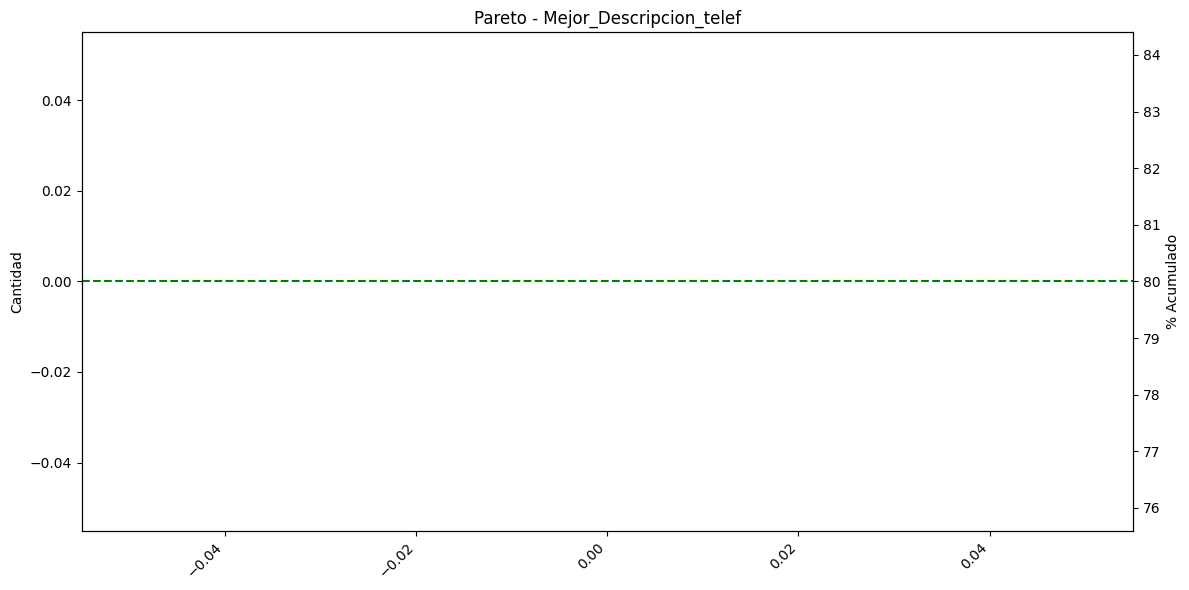

In [129]:

df_dni = df_filtrado.toPandas()
pareto_mejor_descripcion(df_dni,tipificaicon_telf)

In [48]:

exportar_lista(df_filtrado,'tc_cenco_202603301418.xlsx','linea_cencosud')

In [50]:
cantidad_leads=df_filtrado.count()

In [56]:
info_list=f"""
Se tienen {cantidad_leads} leads
Prioridad : {quintil}
maximo de intentos por num telef: {q_intentos_telef}
flg_ex_cliente :{flg_ex_cliente}
{segmento}
{first_name}

"""

print(info_list)


Se tienen 2814 leads
Prioridad : ['1', '2']
maximo de intentos por num telef: 40
flg_ex_cliente :['NUEVO']
['TC2', 'TC1']
['SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']




In [79]:
exportar_lista(df_filtrado,'tc_cencor_202603310847.xlsx','linea_cencosud')

['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'NUMERO DESCONECTADO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [ ]:
import os

ruta_archivo = os.path.join(ruta_csv, 'ivr_202603271706.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [142]:

df_dni = df_filtrado.toPandas()


In [73]:
los pu pm los qu epodemos usar


SyntaxError: invalid syntax (2290498890.py, line 1)

In [12]:

nombre_archivo_xlsx='SAE_202603251722.xlsx'
columna_ref='linea_sae'
exportar_lista(df_filtrado,nombre_archivo_xlsx,columna_ref)


In [ ]:
fecha_mes_base='2026-03-01'
t_maestra='Base_Maestra_Cencosud_PPFF'
t_name_vigente='Base_Maestra_Cencosud_PPFF_vigente'
t_mumeros='tNumeroCenco_Sae'
cols_drop=[ 'FRESCURA_TARGET', 'REP1', 'REP2', 'REP3','FLAT2']


In [97]:
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
)
df_dni = df_filtrado.toPandas()

In [ ]:
import matplotlib.pyplot as plt

df_dni['email'].value_counts().plot(kind='bar')

plt.title('Top departamentos (email)')
plt.xlabel('Departamento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [8]:
df_list.select('retiro_01').filter(col('retiro_01')==0).count()

2266

In [13]:
# print([row['first_name'] for row in df_list.select('first_name').distinct().collect()])
# print([row['title'] for row in df_list.select('title').distinct().collect()])
# print([row['tip_prioridad'] for row in df_list.select('tip_prioridad').distinct().collect()])
# print([row['email'] for row in df_list.select('email').distinct().collect()])
# print([row['prioridada'] for row in df_list.select('prioridada').distinct().collect()])
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])
# print(df_list.columns)


['PERSONA FALLECIDA', 'VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'NEGOCIO EN ZONA NO COBERTURADA', 'TITULAR CONTAGIADO CON COVID - 19', 'CREDITO CONCRETADO', 'MENSAJES CON TERCEROS - HIJOS', 'NO DESEA SER CONTACTADO / MANIFIESTA SU RECHAZO', 'NO NECESITA / NO DESEA', 'TELEFONO APAGADO', 'NUMERO EQUIVOCADO', 'ESTA ENDEUDADO', 'MENSAJES CON TERCEROS - ESPOSA', 'OTROS', 'NO CONTESTA ', 'TITULAR NO CALIFICA- GIRO RESTRINGIDO9', 'CLIENTE RECHAZADO', 'MENSAJES CON TERCEROS - OTROS', 'NO BRINDA CONSENTIMIENTO', 'CASA EN ZONA NO COBERTURADA', 'SI QUIERE', 'CLIENTE DE VIAJE', 'TELEFONO FUERA DE SERVICIO/SUSPENDIDO', 'CONFIRMAR CITA', 'INTERESES ELEVADOS', 'NUMERO NO EXISTE', 'TITULAR NO CALIFICA - DESEMPLEO', 'MENSAJES DE TEXTO', 'TONO OCUPADO', 'SOLICITA SER RETIRADO', 'IVR - NO CONFIRMA', 'MALA EXPERIENCIA (TDA/FNC)', 'DESEA MAS MONTO', 'NO QUIERE', None]


validar

In [ ]:
fecha_mes_base='2026-04-01'
tipi_cond1='DINERS'
tipi_cond2='CD'
tipi_cond3='xx'
tb_tipolofia='tTipologia_Diners_PPD'
servidor_01=21
tipi_cod='cod'
tipi_resp_cod='P'
tipi_descrip='[NIVEL 4]'
tipi_estado='[NIVEL 2]'
tipi_resp_estado='NO CONTACTO'
tipi_subdescripcion='[NIVEL 3]'
tnum_tb='tNumeroDiners'
tnum_dni='NumDoc'
tlista_generada='borrar_prestamo_dinner'
get_base=since_base_maestra_pp_dinners

In [17]:
query = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor_01}], '
        SELECT        
        rtrim(ltrim(d.vendor_lead_code)) AS vendor_lead_code,        
        e.dial_method,
        a.campaign_id AS numero_campana,        
        a.user AS dni_ejecutivo,
        c.full_name AS ejecutivo,
        e.campaign_name AS nombre_campana,        
        a.call_date AS fecha_hora_llamada,        
        a.length_in_sec AS duracion,        
        b.status_name AS call_result,        
        f.list_description,        
        f.list_name,        
        a.phone_number as phone_number,        
        d.alt_phone as fecha_agenda,        
        d.comments as comentarios,        
        a.status AS codigo
        FROM asterisk.vicidial_log a         
        LEFT JOIN asterisk.vicidial_list d ON a.lead_id=d.lead_id        
        LEFT JOIN asterisk.vicidial_campaigns e ON a.campaign_id=e.campaign_id        
        LEFT JOIN asterisk.vicidial_lists f ON a.list_id=f.list_id        
        LEFT JOIN asterisk.vicidial_statuses b ON a.status=b.status        
        LEFT JOIN asterisk.vicidial_users c ON a.user=c.user        
        WHERE (e.campaign_name like "%{tipi_cond1}" or e.campaign_name like "%{tipi_cond2}" or e.campaign_name like "%{tipi_cond3}")
        AND a.call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')
        AND a.call_date < 
        DATE_ADD(DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''), INTERVAL 1 MONTH)
    ')

    """
df_vicidial=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

+----------------+--------------------+--------------+-------------+--------------------+-----------------+-------------------+--------+--------------------+--------------------+--------------------+------------+------------+--------------------+------+
|vendor_lead_code|         dial_method|numero_campana|dni_ejecutivo|           ejecutivo|   nombre_campana| fecha_hora_llamada|duracion|         call_result|    list_description|           list_name|phone_number|fecha_agenda|         comentarios|codigo|
+----------------+--------------------+--------------+-------------+--------------------+-----------------+-------------------+--------+--------------------+--------------------+--------------------+------------+------------+--------------------+------+
|        08772894|RATIO            ...|           401|         VDAD|  Outbound Auto Dial|2026-04 DINERS CD|2026-04-22 15:58:18|       0|Answering Machine...|cd_dinner_2026042...|cd_dinner_2026042...|   949144156|            |,Deuda_BCP: 2

In [13]:
db_kishin

'DANTALION'

In [ ]:
overwrite_table_SQL(spark,df_ref01,f'{tb_name_tnum}',server_kishin,user_kishin,pwd_kishin,db_kishin)


In [19]:
query = f"""
    SELECT * from DANTALION.dbo.tNumero_alfcc_borrar_01
    """
df_validas=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)



In [20]:
df_tnumeric=since_tnumeros_valentina(spark,'alfcc_clientes','2026-04-01')


In [21]:
print(df_validas.columns)
print(df_tnumeric.columns)

['dni_cliente', 'contacto', 'tipo_telf', 'dias_antiguedad']
['dni_cliente', 'contacto', 'tipo_telf']


In [23]:
spark.stop()